# Working with OpticalSystem Objects

This tutorial is designed to give an overview of the main class in dLux - The `OpticalSystem` class. 

In [1]:
## COLLAPSE: Imports
# Basic imports
import jax.numpy as np

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

## Overview

There are three `OpticalSystem`s implemented in dLux:

1. `LayeredOpticalSystem`
2. `AngularOpticalSystem`
3. `CartesianOpticalSystem`

All are constructed similarly, and share the the following attributes:

- `wf_npixels`
- `diameter`
- `layers`

The `wf_npixls` parameter defines the number of pixels used to initialise the wavefront, `diameter` defines the diameter of the wavefront in meters, and `layers` is a list of `OpticalLayer` objects that define the transformations to that wavefront.

The `AngularOpticalSystem` and `CartesianOpticalSystem` are both subclasses of the `LayeredOpticalSystem` class, extending it to include three extra attributes:

- `psf_npixels`
- `psf_pixel_scale`
- `oversample`

These attributes define the size of the PSF, the pixel scale of the PSF, and the oversampling factor used when calculating the PSF. The difference between the two is that the `AngularOpticalSystem` has `psf_pixel_scale` in units of arcseconds, while the `CartesianOpticalSystem` has `psf_pixel_scale` in units of microns. Note that an oversample of 2 will result in an output psf with shape `(2 * psf_npixels, 2 * psf_npixels)`, with the idea that the PSF will be downsampled later to the correct size and pixel scale. 

Beyond this, the `CartesianOpticalSystem` has an extra attribute `focal_length`, with units of meters.

Now lets create a minimal `AnguarOpticalSystem` to demonstrate how to use these classes.

In [2]:
# Define our wavefront properties
wf_npix = 512  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Construct a simple circular aperture
coords = dlu.pixel_coords(wf_npix, diameter)
aperture = dlu.circle(coords, 0.5 * diameter)

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds
oversample = 3  # Oversampling factor for the PSF

# Define the optical layers
layers = [('aperture', dl.layers.Optic(aperture, normalise=True))]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npix, diameter, layers, psf_npix, psf_pixel_scale, oversample
)

# Get the extents for plotting
aper_ext = dlu.imshow_extent(optics.diameter)
psf_ext = dlu.imshow_extent(optics.fov)

# Let examine the optics object! The dLux framework has in-built
# pretty-printing, so we can just print the object to see what it contains.
print(optics)

AngularOpticalSystem(
  wf_npixels=512,
  diameter=1.0,
  layers={
    'aperture':
    Optic(opd=None, phase=None, transmission=f32[512,512], normalise=True)
  },
  psf_npixels=64,
  oversample=3,
  psf_pixel_scale=0.05
)



## Methods

All three of these object are quite similar, and share the same two primary methods:

1. `.propagate_mono`
2. `.propagate`

Lets look at them one at a time

## `propagate_mono`

`propagate_mono` has the following signature: `optics.propagate_mono(wavelength, offset=np.zeros(2), return_wf=False)`

- `wavelength` is the wavelength of the light to propagate, in meters
- `offset` is the offset of the source from the center of optical system, in radians
- `return_wf` is a boolean flag that determines whether the wavefront object should be returned, as opposed to the psf array.

Note that the `propagate_mono` method should generally not be used, as its functionality is superceeded by the `propagate` method, but lets look at how it works anyway.

In [3]:
# 1 micron wavelength
wavelength = 1e-6 

# 5-pixel offset in the x-direction
shift = np.array([5 * psf_pixel_scale, 0])
offset = dlu.arcsec2rad(shift)

# Propagate a psf
psf = optics.propagate_mono(wavelength, offset)

# Propagate the Wavefront
wf = optics.propagate_mono(wavelength, offset, return_wf=True)

# Look at our objects
print(psf.shape)
print(wf)

(192, 192)
Wavefront(
  wavelength=f32[],
  pixel_scale=f32[],
  phasor=c64[192,192],
  plane='Focal',
  units='Angular'
)


Now lets plot our results to see what we get.

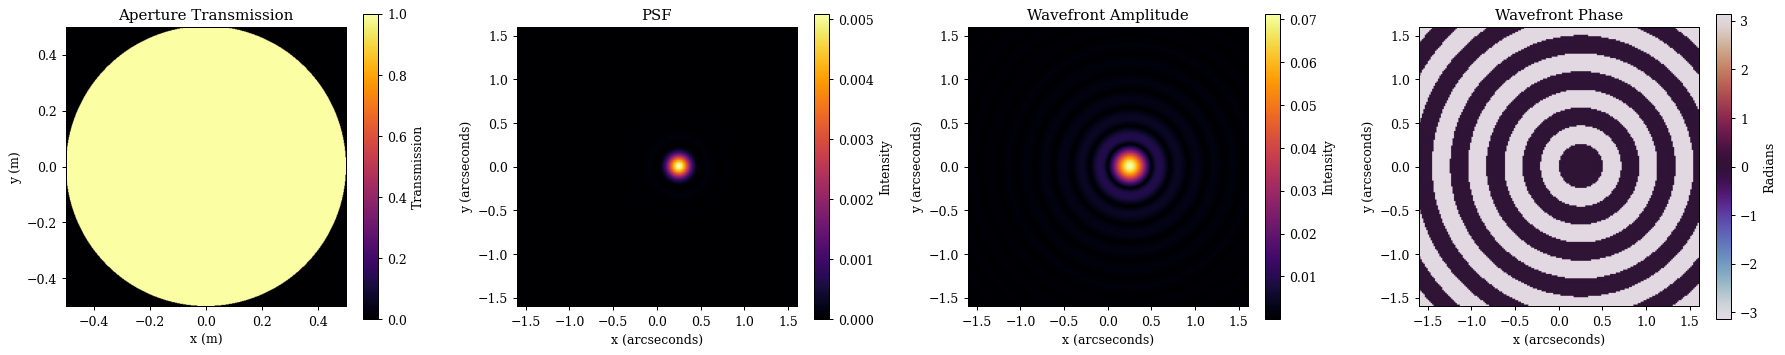

In [4]:
## COLLAPSE: Plotting code
# Plot the results
plt.figure(figsize=(20, 4))
ax = plt.subplot(1, 4, 1)
im = ax.imshow(optics.transmission, extent=aper_ext)
plt.colorbar(im, ax=ax, label="Transmission")
ax.set(title="Aperture Transmission", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 4, 2)
im = ax.imshow(psf, extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 4, 3)
im = ax.imshow(wf.amplitude, extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="Wavefront Amplitude", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 4, 4)
im = ax.imshow(wf.phase, "twilight", extent=psf_ext)
plt.colorbar(im, ax=ax, label="Radians")
ax.set(title="Wavefront Phase", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

## `propagate`

`propagate` is the core propagation function of optical systems. It has the following signature: `optics.propagate(wavelengths, offsets=np.zeros(2), weights=None, return_wf=False, return_psf=False)`


- `wavelengths` is an array of wavelengths to propagate, in meters
- `offset` is the offset of the source from the center of optical system, in radians
- `weights` is an array of weights to apply to each wavelength. If `None`, then all wavelengths are weighted equally.
- `return_wf` is a boolean flag that determines whether the `Wavefront` object should be returned, as opposed to the psf array.
- `return_psf` is a boolean flag that determines whether the `PSF` object should be returned, as opposed to the psf array.

Lets see how to ues it.

In [5]:
# Wavelengths array - Note we can also pass in a single float value!
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)

# Weights array - Note these are relative weights, the input
# is automatically normalised
weights = np.linspace(0.5, 1.5, len(wavelengths))

# 5-pixel offset in the x-direction
shift = np.array([5 * psf_pixel_scale, 0])
offset = dlu.arcsec2rad(shift)

# Propagate a psf
psf = optics.propagate(wavelengths, offset, weights)
wf = optics.propagate(wavelengths, offset, weights, return_wf=True)

# Look at our objects
print(psf.shape)
print(wf)

(192, 192)
Wavefront(
  wavelength=f32[10],
  pixel_scale=f32[10],
  phasor=c64[10,192,192],
  plane='Focal',
  units='Angular'
)


Interesting, as we can see the returned `Wavefront` object in _vectorised_ down its first axis. This is one of the benfits of working within the `Equinox`/`Zodiax` framework, as we can vectorise our objects _directly_ meaning we dont need to updack values into arrays to be vectorised. Note that we plot the _mean_ phase here, but that doesn't really have a physical meaning as the phase is only defined for a monochromatric wavefront, but it gives us an idea of the phase structure of the wavefront.

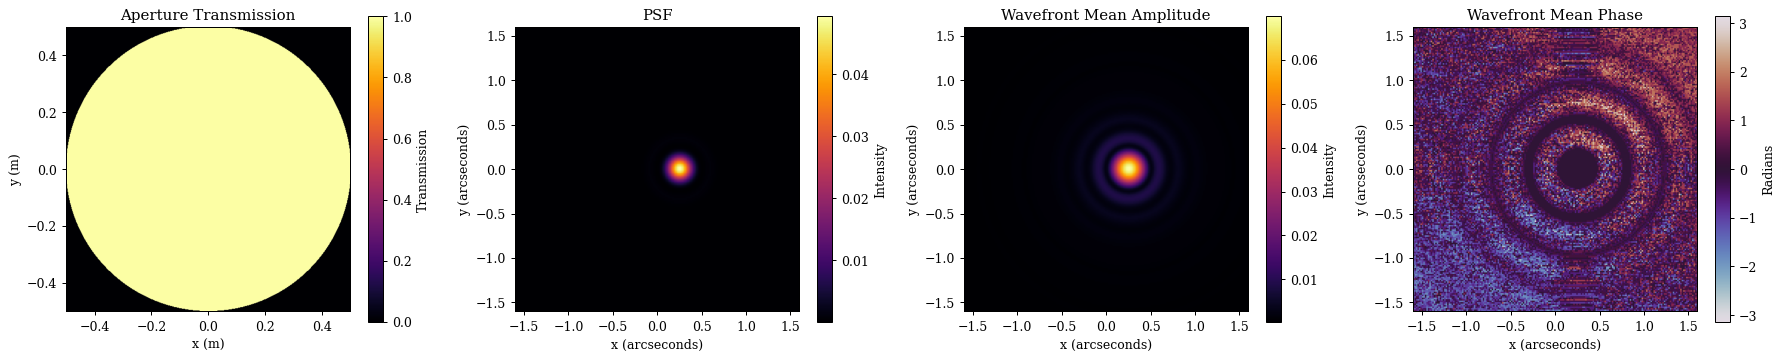

In [6]:
## COLLAPSE: Plotting code
# Plot the results
plt.figure(figsize=(20, 4))
ax = plt.subplot(1, 4, 1)
im = ax.imshow(optics.transmission, extent=aper_ext)
plt.colorbar(im, ax=ax, label="Transmission")
ax.set(title="Aperture Transmission", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 4, 2)
im = ax.imshow(psf, extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 4, 3)
im = ax.imshow(wf.amplitude.mean(0), extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="Wavefront Mean Amplitude", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 4, 4)
im = ax.imshow(wf.phase.mean(0), "twilight", extent=psf_ext)
plt.colorbar(im, ax=ax, label="Radians")
ax.set(title="Wavefront Mean Phase", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

We can also return the `PSF` object too, allowing us to keep track of the pixel scale and perform operations like downsampling. Lets have a look at that now

In [7]:
# Get the PSF object
PSF = optics.propagate(wavelengths, offset, weights, return_psf=True)

# Downsample the PSF to the 'true' pixel scale
true_PSF = PSF.downsample(oversample)

# Lets examine it, and plot it
print(true_PSF)

PSF(data=f32[64,64], pixel_scale=f32[])


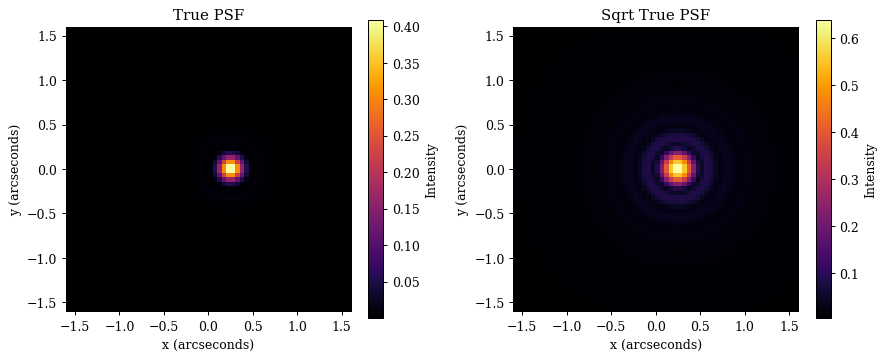

In [8]:
## COLLAPSE: Plotting code
# Plot
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 2, 1)
im = ax.imshow(true_PSF.data, extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="True PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 2, 2)
im = ax.imshow(true_PSF.data**0.5, extent=psf_ext)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="Sqrt True PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

## Summary

Thats all there is to it! These objects are designed to be simple to use, and to be as flexible as possible.